In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the iris dataset
iris = datasets.load_iris()
X = iris.data  # Feature matrix (150 samples, 4 features)
y = iris.target  # Target labels (0 = Setosa, 1 = Versicolor, 2 = Virginica)

# Convert to DataFrame for better visualization
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y

# Display first few rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
pca = PCA(n_components=2)  # Reduce to 2 components
X_pca = pca.fit_transform(X_scaled)

In [4]:
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)
print("Total Variance Explained:", np.sum(explained_variance))


Explained Variance Ratio: [0.72962445 0.22850762]
Total Variance Explained: 0.9581320720000166


```💡 Interpretation: If the first two components explain >90% of the variance, they are sufficient.```

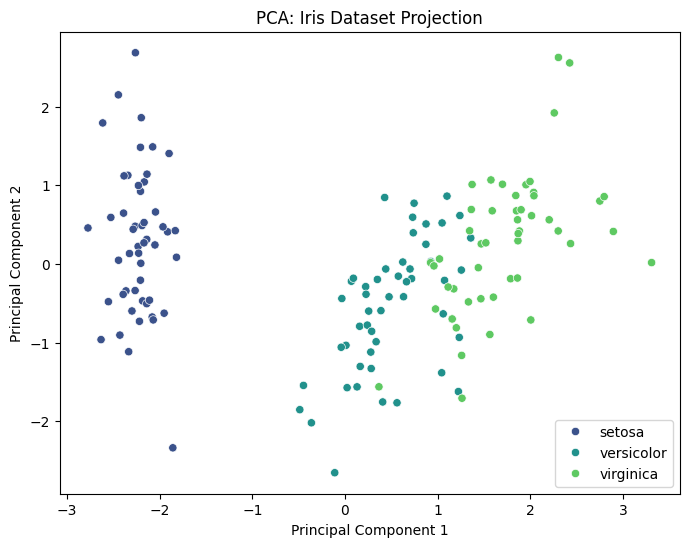

In [5]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=iris.target_names[y], palette='viridis')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: Iris Dataset Projection")
plt.legend()
plt.show()

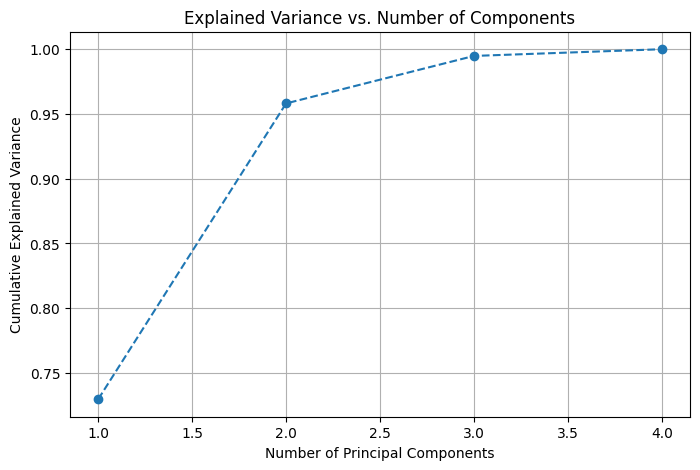

In [6]:
pca_full = PCA()  # PCA without limiting components
X_pca_full = pca_full.fit_transform(X_scaled)

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs. Number of Components")
plt.grid()
plt.show()


💡 Interpretation:

If we see a point where the curve flattens, that’s the optimal number of components.

Usually, 95%+ variance is a good threshold.

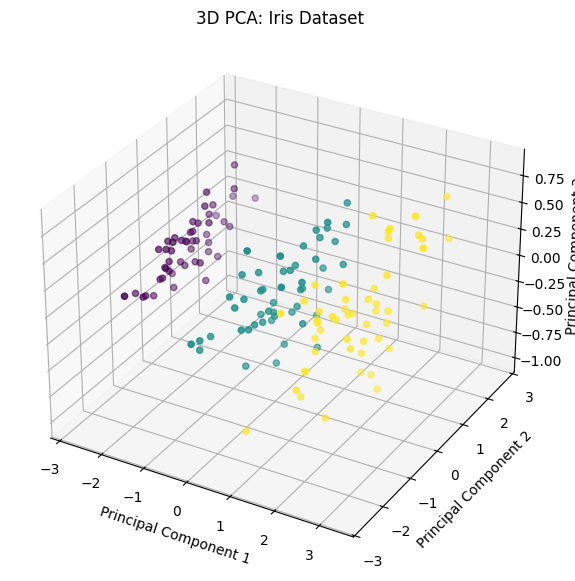

In [7]:
from mpl_toolkits.mplot3d import Axes3D

# Apply PCA with 3 components
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# 3D Scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=y, cmap='viridis')

# Labels
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D PCA: Iris Dataset")

plt.show()

```Find Important Features Using PCA
First, we check how much variance each feature contributes to help us select the best ones.```

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [10]:
# Apply PCA
pca = PCA(n_components=4)  # Keep all components initially
X_pca = pca.fit_transform(X_scaled)

# Find contribution of each original feature to principal components
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(4)], index=feature_names)
print(loadings)

                        PC1       PC2       PC3       PC4
sepal length (cm)  0.521066  0.377418  0.719566 -0.261286
sepal width (cm)  -0.269347  0.923296 -0.244382  0.123510
petal length (cm)  0.580413  0.024492 -0.142126  0.801449
petal width (cm)   0.564857  0.066942 -0.634273 -0.523597


```💡 Interpretation:

Higher absolute values in a column show which original features contribute the most to that principal component.

If a feature has low contribution in all PCs, it may be removed```

In [11]:
# Select top features based on highest contributions in the first few PCs
top_features = loadings.abs().sum(axis=1).sort_values(ascending=False).index[:2]  # Selecting top 2
print("Selected Features:", list(top_features))

# Use only selected features
X_selected = X_scaled[:, [feature_names.index(f) for f in top_features]]

Selected Features: ['sepal length (cm)', 'petal width (cm)']


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split data (original vs selected)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train_selected, X_test_selected, _, _ = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Train model on original dataset
model_full = RandomForestClassifier(random_state=42)
model_full.fit(X_train, y_train)
y_pred_full = model_full.predict(X_test)
accuracy_full = accuracy_score(y_test, y_pred_full)

# Train model on reduced dataset
model_selected = RandomForestClassifier(random_state=42)
model_selected.fit(X_train_selected, y_train)
y_pred_selected = model_selected.predict(X_test_selected)
accuracy_selected = accuracy_score(y_test, y_pred_selected)

# Print results
print(f"Accuracy with Full Features: {accuracy_full:.2f}")
print(f"Accuracy with Selected Features: {accuracy_selected:.2f}")

Accuracy with Full Features: 1.00
Accuracy with Selected Features: 0.97
